# ⚽ LaLiga Teams — Eksplorasi Data & Clustering Gaya Bermain

Notebook ini membangun data **Gold layer** dari CSV clean (Silver), lalu melakukan:
1. **Eksplorasi data** — statistik deskriptif, korelasi, distribusi
2. **ML Clustering** — K-Means clustering untuk mengelompokkan tim berdasarkan gaya bermain
3. **Visualisasi** — Radar chart, PCA, heatmap

> **Catatan**: Notebook ini membaca langsung dari `data/silver/teams/csv_clean/` (simulasi Gold layer via Pandas).
> Jika sudah ada PostgreSQL, ganti cell pertama dengan `pd.read_sql()`.

## 1. Setup & Import

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Data — Build Gold OBT dari CSV Clean

In [34]:
# Path config
BASE_DIR = Path.cwd().parent  # root project
SILVER_CLEAN = BASE_DIR / "data" / "silver" / "teams" / "csv_clean"

# Load semua 6 tabel silver
attacking  = pd.read_csv(SILVER_CLEAN / "teams_attacking.csv")
defending  = pd.read_csv(SILVER_CLEAN / "teams_defending.csv")
passing    = pd.read_csv(SILVER_CLEAN / "teams_passing.csv")
pressing   = pd.read_csv(SILVER_CLEAN / "teams_pressing.csv")
sequences  = pd.read_csv(SILVER_CLEAN / "teams_sequences.csv")
misc       = pd.read_csv(SILVER_CLEAN / "teams_misc.csv")

print(f"attacking:  {attacking.shape}")
print(f"defending:  {defending.shape}")
print(f"passing:    {passing.shape}")
print(f"pressing:   {pressing.shape}")
print(f"sequences:  {sequences.shape}")
print(f"misc:       {misc.shape}")

attacking:  (20, 9)
defending:  (20, 10)
passing:    (20, 17)
pressing:   (20, 9)
sequences:  (20, 10)
misc:       (20, 13)


In [35]:
# Build Gold OBT — JOIN semua tabel on 'club'
gold = attacking.merge(defending, on=['club', 'played'], suffixes=('', '_def'))
gold = gold.merge(passing.drop(columns=['avg_possession_pct']), on=['club', 'played'])
gold = gold.merge(pressing, on=['club', 'played'])
gold = gold.merge(sequences, on=['club', 'played'])
gold = gold.merge(misc, on='club')

# Rename kolom agar match dengan DDL gold (prefix per kategori)
rename_map = {
    # attacking
    'goals': 'att_goals', 'xg': 'att_xg', 'goals_vs_xg': 'att_goals_vs_xg',
    'shots': 'att_shots', 'sot': 'att_sot', 'conversion_pct': 'att_conversion_pct',
    'xg_per_shot': 'att_xg_per_shot',
    # defending
    'avg_possession_pct': 'def_avg_possession_pct', 'tackles': 'def_tackles',
    'interceptions': 'def_interceptions', 'possession_won': 'def_possession_won',
    'blocks': 'def_blocks', 'clearances': 'def_clearances',
    'ground_duels_won_pct': 'def_ground_duels_won_pct', 'aerial_duels_won_pct': 'def_aerial_duels_won_pct',
    # passing
    'passes_total': 'pas_passes_total', 'passes_successful': 'pas_passes_successful',
    'passes_pct': 'pas_passes_pct', 'final_third_total': 'pas_final_third_total',
    'final_third_successful': 'pas_final_third_successful', 'final_third_pct': 'pas_final_third_pct',
    'direction_fwd_pct': 'pas_direction_fwd_pct', 'direction_bwd_pct': 'pas_direction_bwd_pct',
    'direction_left_pct': 'pas_direction_left_pct', 'direction_right_pct': 'pas_direction_right_pct',
    'crosses_total': 'pas_crosses_total', 'crosses_successful': 'pas_crosses_successful',
    'crosses_pct': 'pas_crosses_pct', 'through_balls': 'pas_through_balls',
    # pressing
    'pressed_seqs': 'prs_pressed_seqs', 'ppda': 'prs_ppda', 'start_distance': 'prs_start_distance',
    'high_turnovers_total': 'prs_high_turnovers_total',
    'high_turnovers_shot_ending': 'prs_high_turnovers_shot_ending',
    'high_turnovers_goal_ending': 'prs_high_turnovers_goal_ending',
    'high_turnovers_shot_pct': 'prs_high_turnovers_shot_pct',
    # sequences
    'passes_10_plus': 'seq_passes_10_plus', 'direct_speed': 'seq_direct_speed',
    'passes_per_seq': 'seq_passes_per_seq', 'sequence_time': 'seq_sequence_time',
    'buildups_total': 'seq_buildups_total', 'buildups_goals': 'seq_buildups_goals',
    'direct_attacks_total': 'seq_direct_attacks_total', 'direct_attacks_goals': 'seq_direct_attacks_goals',
    # misc
    'subs_used': 'msc_subs_used', 'subs_goals': 'msc_subs_goals',
    'errors_lead_to_shot': 'msc_errors_lead_to_shot', 'errors_lead_to_goal': 'msc_errors_lead_to_goal',
    'fouled': 'msc_fouled', 'yellows': 'msc_yellows', 'reds': 'msc_reds',
    'pens_won': 'msc_pens_won', 'fouls': 'msc_fouls', 'opp_yellows': 'msc_opp_yellows',
    'opp_reds': 'msc_opp_reds', 'pens_conceded': 'msc_pens_conceded',
}
gold = gold.rename(columns=rename_map)

# Add derived per-game metrics
played = gold['played']
gold['att_goals_per_game'] = (gold['att_goals'] / played).round(2)
gold['att_shots_per_game'] = (gold['att_shots'] / played).round(2)
gold['att_xg_per_game'] = (gold['att_xg'] / played).round(2)
gold['def_tackles_per_game'] = (gold['def_tackles'] / played).round(2)
gold['def_interceptions_per_game'] = (gold['def_interceptions'] / played).round(2)
gold['pas_passes_per_game'] = (gold['pas_passes_total'] / played).round(2)
gold['pas_crosses_per_game'] = (gold['pas_crosses_total'] / played).round(2)
gold['pas_through_balls_per_game'] = (gold['pas_through_balls'] / played).round(2)
gold['prs_pressed_seqs_per_game'] = (gold['prs_pressed_seqs'] / played).round(2)
gold['seq_buildups_per_game'] = (gold['seq_buildups_total'] / played).round(2)
gold['seq_direct_attacks_per_game'] = (gold['seq_direct_attacks_total'] / played).round(2)
gold['msc_fouls_per_game'] = (gold['msc_fouls'] / played).round(2)
gold['msc_yellows_per_game'] = (gold['msc_yellows'] / played).round(2)

gold = gold.set_index('club')
print(f"✅ Gold OBT: {gold.shape[0]} teams × {gold.shape[1]} columns")
gold.head(3)

✅ Gold OBT: 20 teams × 70 columns


,played,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,def_avg_possession_pct,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_ground_duels_won_pct,def_aerial_duels_won_pct,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_total,pas_final_third_successful,pas_final_third_pct,pas_direction_fwd_pct,pas_direction_bwd_pct,pas_direction_left_pct,pas_direction_right_pct,pas_crosses_total,pas_crosses_successful,pas_crosses_pct,pas_through_balls,prs_pressed_seqs,prs_ppda,prs_start_distance,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_passes_10_plus,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_buildups_goals,seq_direct_attacks_total,seq_direct_attacks_goals,msc_subs_used,msc_subs_goals,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_fouled,msc_yellows,msc_reds,msc_pens_won,msc_fouls,msc_opp_yellows,msc_opp_reds,msc_pens_conceded,att_goals_per_game,att_shots_per_game,att_xg_per_game,def_tackles_per_game,def_interceptions_per_game,pas_passes_per_game,pas_crosses_per_game,pas_through_balls_per_game,prs_pressed_seqs_per_game,seq_buildups_per_game,seq_direct_attacks_per_game,msc_fouls_per_game,msc_yellows_per_game
club,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Barcelona,38,95,86.62,8.38,692,257,13.73,0.13,68.8,618,280,1756,95,716,53.2,57.7,24800,22316,90.0,7168,5850,81.6,25.7,15.1,29.1,30.1,391,89,22.8,121,471,8.7,43.9,294,51,10,17.35,845,1.68,5.19,14.22,231,10,65,9,184,18,22,3,433,59,2,10,348,89,8,5,2.50,18.21,2.28,16.26,7.37,652.63,10.29,3.18,12.39,6.08,1.71,9.16,1.55
Real Madrid,38,77,78.00,-1.00,665,253,11.58,0.12,59.4,591,252,1776,124,639,54.3,56.9,22307,20002,89.7,7008,5743,82.0,27.7,14.7,29.1,28.5,360,68,18.9,97,415,11.5,43.3,279,65,11,23.30,724,1.74,4.91,13.55,169,14,103,7,171,6,27,5,522,68,7,14,359,79,10,4,2.03,17.50,2.05,15.55,6.63,587.03,9.47,2.55,10.92,4.45,2.71,9.45,1.79
Villarreal,38,72,59.04,12.96,455,172,15.82,0.13,44.5,655,331,1784,158,1026,49.1,47.9,15550,12927,83.1,4128,2938,71.2,31.6,13.4,27.6,27.3,331,73,22.1,80,367,15.1,38.9,218,23,3,10.55,352,1.99,3.48,9.28,75,4,90,12,184,8,42,13,444,77,3,7,427,76,3,8,1.89,11.97,1.55,17.24,8.71,409.21,8.71,2.11,9.66,1.97,2.37,11.24,2.03


## 3. Eksplorasi Data

### 3.1 Statistik Deskriptif

In [36]:
gold.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
played,20.0,38.00,0.00,38.00,38.00,38.00,38.00,38.00
att_goals,20.0,51.20,15.97,26.00,43.00,46.50,59.00,95.00
att_xg,20.0,51.49,12.84,30.59,45.34,49.36,54.72,86.62
att_goals_vs_xg,20.0,-0.29,6.77,-12.19,-5.80,0.20,3.77,12.96
att_shots,20.0,474.30,86.12,352.00,422.00,459.00,504.00,692.00
...,...,...,...,...,...,...,...,...
prs_pressed_seqs_per_game,20.0,10.72,1.51,7.71,9.95,10.50,11.25,14.66
seq_buildups_per_game,20.0,2.00,1.34,0.24,1.26,1.48,2.31,6.08
seq_direct_attacks_per_game,20.0,1.47,0.51,0.47,1.21,1.39,1.69,2.71
msc_fouls_per_game,20.0,11.90,1.56,9.16,11.01,11.78,12.84,14.26


### 3.2 Top & Bottom Teams per Metrik

/var/folders/mm/qxk0j36n0xx3dqwlgzl5rfy40000gn/T/ipykernel_43918/3157671574.py:22: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mm/qxk0j36n0xx3dqwlgzl5rfy40000gn/T/ipykernel_43918/3157671574.py:22: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mm/qxk0j36n0xx3dqwlgzl5rfy40000gn/T/ipykernel_43918/3157671574.py:22: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mm/qxk0j36n0xx3dqwlgzl5rfy40000gn/T/ipykernel_43918/3157671574.py:22: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mm/qxk0j36n0xx3dqwlgzl5rfy40000gn/T/ipykernel_43918/3157671574.py:22: UserWarning: Glyph 127939 (\N{RUNNER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mm/qxk0j36n0xx3dqwlgzl5rfy40000gn/T/ipykernel_43918/3157671574.py:22: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE 

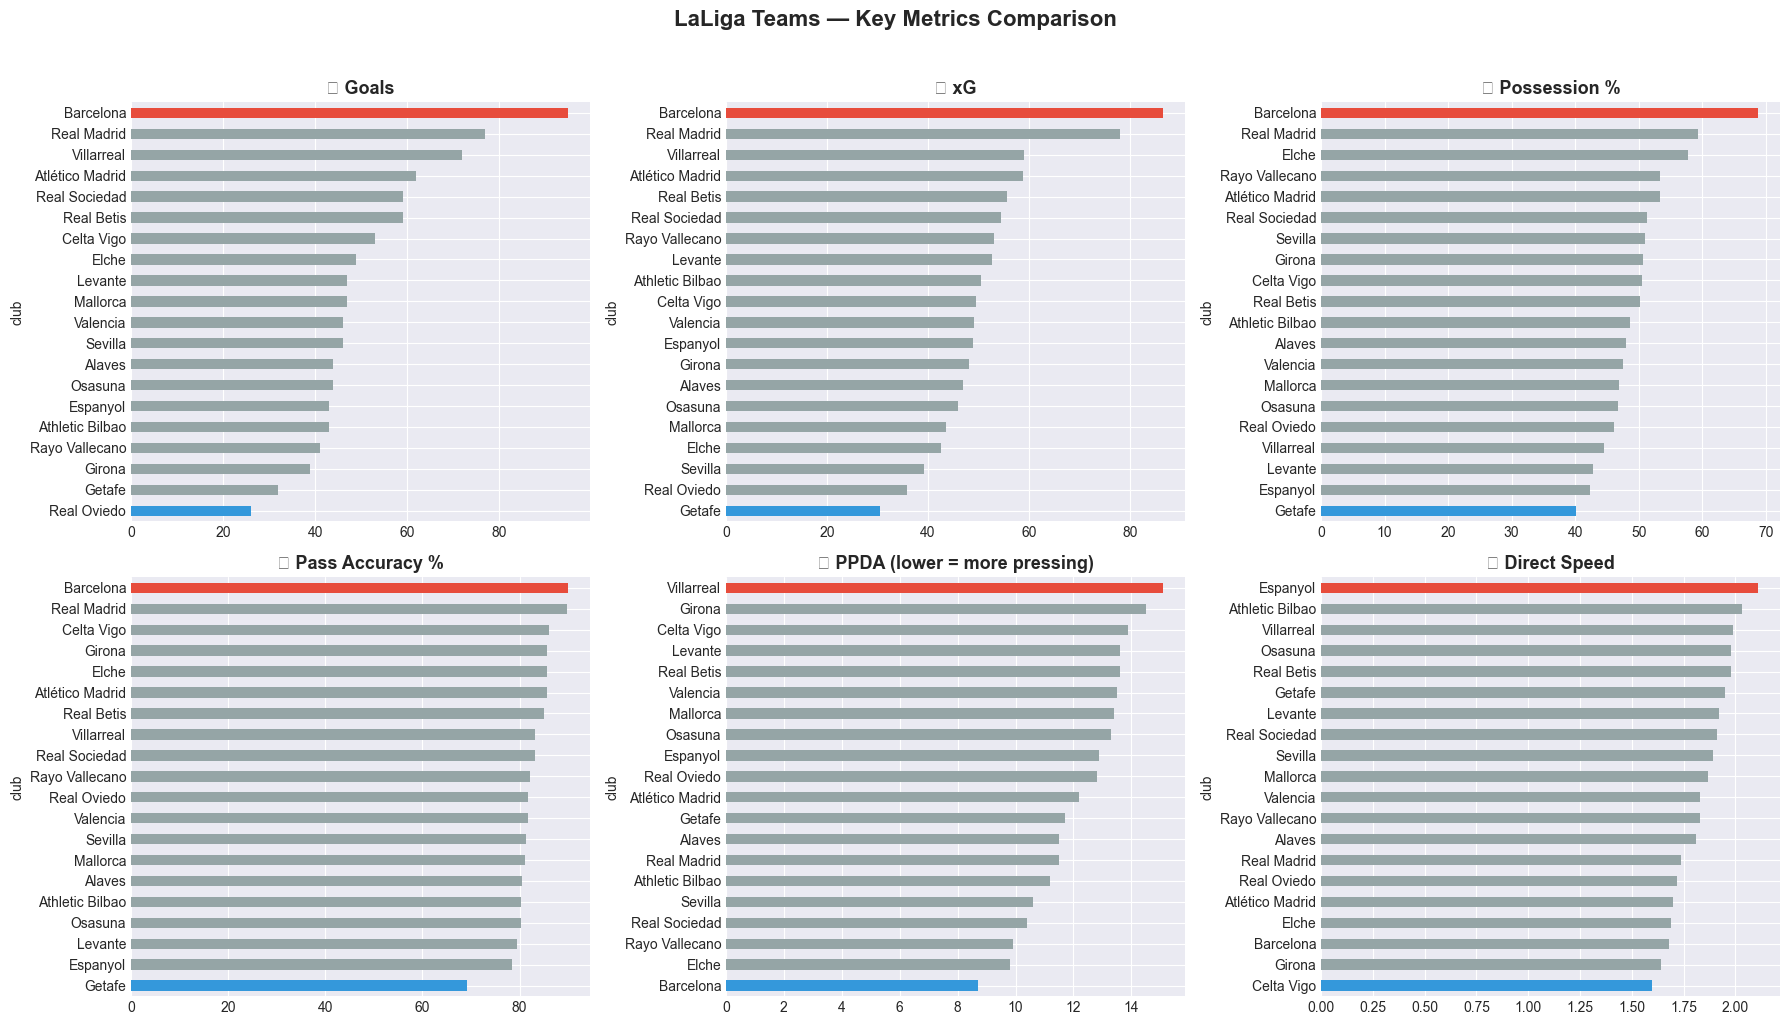

In [37]:
metrics = {
    'att_goals': '⚽ Goals',
    'att_xg': '📊 xG',
    'def_avg_possession_pct': '🔵 Possession %',
    'pas_passes_pct': '🎯 Pass Accuracy %',
    'prs_ppda': '🏃 PPDA (lower = more pressing)',
    'seq_direct_speed': '⚡ Direct Speed',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(metrics.items()):
    ax = axes[i]
    data = gold[col].sort_values(ascending=True)
    colors = ['#e74c3c' if v == data.max() else '#3498db' if v == data.min() else '#95a5a6' for v in data]
    data.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('LaLiga Teams — Key Metrics Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap (Key Metrics)

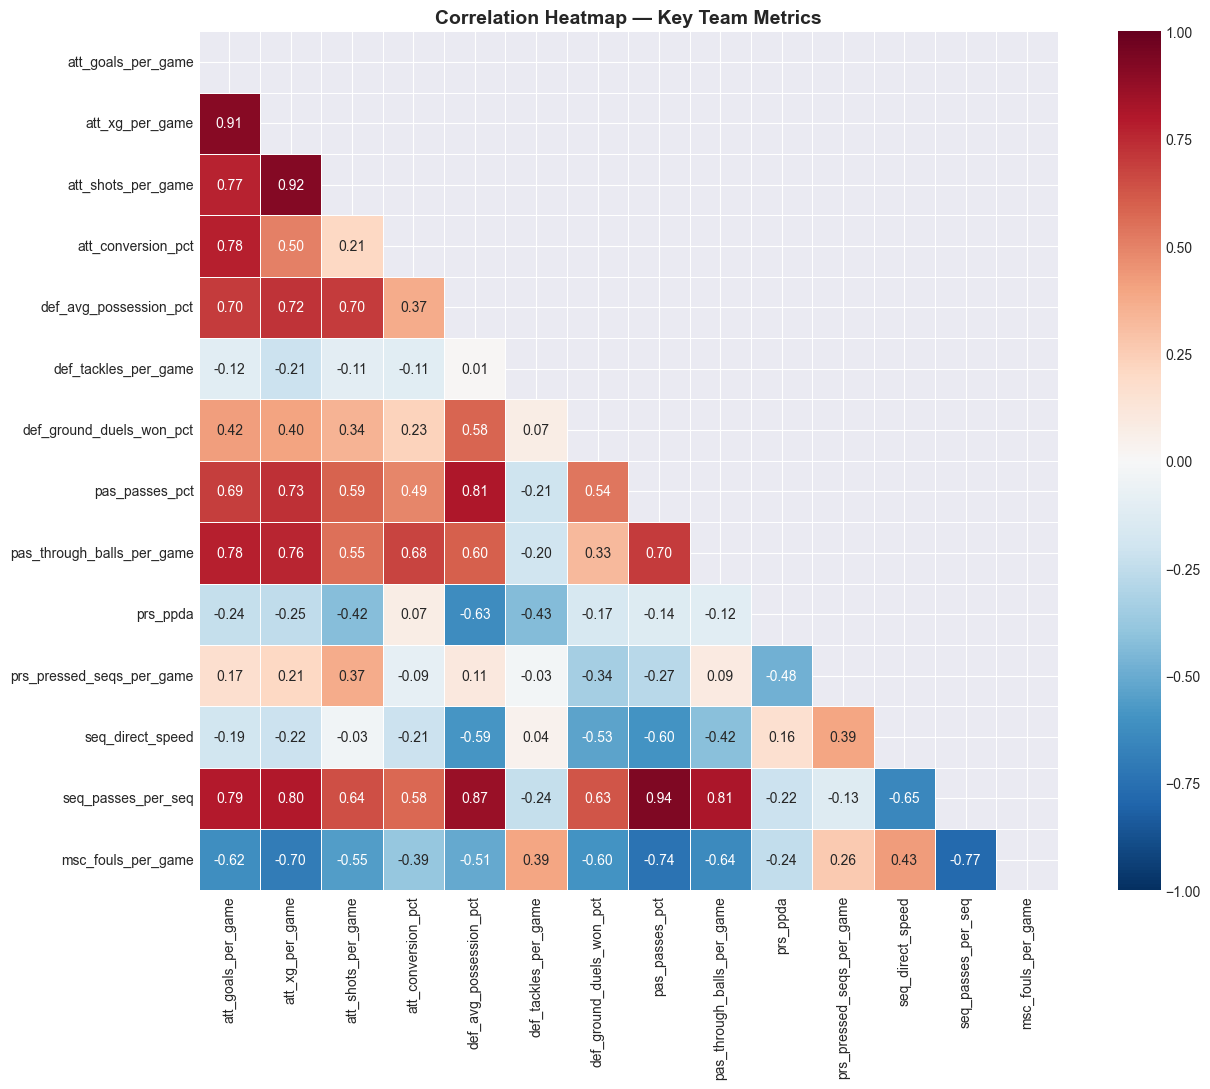

In [38]:
key_cols = [
    'att_goals_per_game', 'att_xg_per_game', 'att_shots_per_game', 'att_conversion_pct',
    'def_avg_possession_pct', 'def_tackles_per_game', 'def_ground_duels_won_pct',
    'pas_passes_pct', 'pas_through_balls_per_game',
    'prs_ppda', 'prs_pressed_seqs_per_game',
    'seq_direct_speed', 'seq_passes_per_seq',
    'msc_fouls_per_game',
]

corr = gold[key_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Key Team Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. ML Clustering — Gaya Bermain Tim

Menggunakan **K-Means** pada fitur-fitur yang menangkap "style" bermain.
Fitur dipilih agar sudah dalam bentuk per-game atau persentase (fair comparison).

### 4.1 Feature Selection

In [39]:
# Fitur clustering — dipilih untuk menangkap dimensi gaya bermain
style_features = [
    # Possession & Passing
    'def_avg_possession_pct',
    'pas_passes_pct',
    'pas_through_balls_per_game',
    'pas_crosses_per_game',
    'pas_direction_fwd_pct',

    # Attacking
    'att_goals_per_game',
    'att_xg_per_game',
    'att_shots_per_game',
    'att_conversion_pct',

    # Pressing
    'prs_pressed_seqs_per_game',
    'prs_ppda',
    'prs_start_distance',

    # Defending
    'def_tackles_per_game',
    'def_interceptions_per_game',
    'def_ground_duels_won_pct',

    # Tempo & Build-up
    'seq_direct_speed',
    'seq_passes_per_seq',
    'seq_sequence_time',
    'seq_buildups_per_game',
    'seq_direct_attacks_per_game',

    # Discipline
    'msc_fouls_per_game',
]

X = gold[style_features].copy()
print(f"Clustering features: {len(style_features)} fitur")
print(f"Data shape: {X.shape}")
X.head()

Clustering features: 21 fitur
Data shape: (20, 21)


,def_avg_possession_pct,pas_passes_pct,pas_through_balls_per_game,pas_crosses_per_game,pas_direction_fwd_pct,att_goals_per_game,att_xg_per_game,att_shots_per_game,att_conversion_pct,prs_pressed_seqs_per_game,prs_ppda,prs_start_distance,def_tackles_per_game,def_interceptions_per_game,def_ground_duels_won_pct,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_per_game,seq_direct_attacks_per_game,msc_fouls_per_game
club,,,,,,,,,,,,,,,,,,,,,
Barcelona,68.8,90.0,3.18,10.29,25.7,2.50,2.28,18.21,13.73,12.39,8.7,43.9,16.26,7.37,53.2,1.68,5.19,14.22,6.08,1.71,9.16
Real Madrid,59.4,89.7,2.55,9.47,27.7,2.03,2.05,17.50,11.58,10.92,11.5,43.3,15.55,6.63,54.3,1.74,4.91,13.55,4.45,2.71,9.45
Villarreal,44.5,83.1,2.11,8.71,31.6,1.89,1.55,11.97,15.82,9.66,15.1,38.9,17.24,8.71,49.1,1.99,3.48,9.28,1.97,2.37,11.24
Atlético Madrid,53.3,85.6,2.63,14.76,30.2,1.63,1.55,13.11,12.45,11.24,12.2,42.3,17.03,7.82,48.6,1.70,4.16,11.03,3.26,1.68,10.50
Real Betis,50.2,85.1,1.79,10.58,31.4,1.55,1.46,14.24,10.91,10.05,13.6,42.0,17.29,9.00,51.4,1.98,3.83,10.30,2.16,2.18,9.74


### 4.2 Standardization

In [40]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

print("✅ Data ter-standardize")
print(f"Mean (should be ~0): {X_scaled.mean(axis=0).round(2)[:3]} ...")
print(f"Std  (should be ~1): {X_scaled.std(axis=0).round(2)[:3]} ...")

✅ Data ter-standardize
Mean (should be ~0): [-0.  0.  0.] ...
Std  (should be ~1): [1. 1. 1.] ...


### 4.3 Optimal K — Elbow Method & Silhouette Score

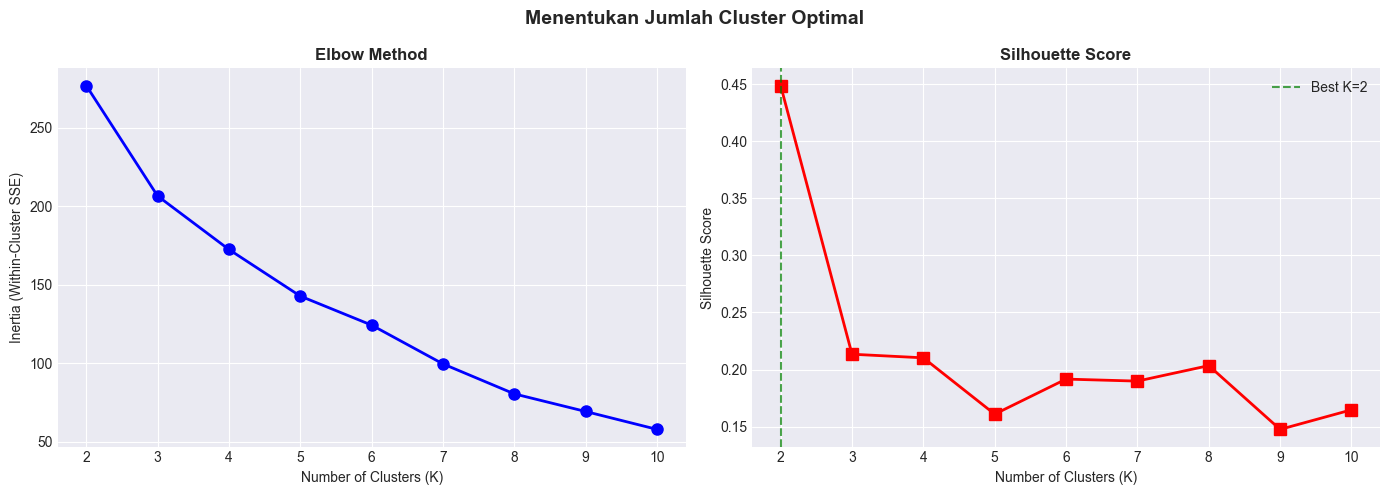


🏆 Optimal K berdasarkan Silhouette: 2 (score: 0.449)


In [41]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-Cluster SSE)')
ax1.set_title('Elbow Method', fontweight='bold')
ax1.set_xticks(list(K_range))

# Silhouette
ax2.plot(K_range, silhouettes, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xticks(list(K_range))

best_k = list(K_range)[np.argmax(silhouettes)]
ax2.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
ax2.legend()

plt.suptitle('Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🏆 Optimal K berdasarkan Silhouette: {best_k} (score: {max(silhouettes):.3f})")

### 4.4 Fit K-Means Final

In [45]:
# Gunakan K optimal dari silhouette (biarkan data yang menentukan)
# FINAL_K = best_k
FINAL_K = 4  # <-- uncomment untuk override manual jika hasil kurang granular

kmeans = KMeans(n_clusters=FINAL_K, n_init=20, random_state=42)
gold['cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means fitted with K={FINAL_K}")
print(f"Silhouette score: {silhouette_score(X_scaled, gold['cluster']):.3f}")
print(f"\nCluster distribution:")
print(gold['cluster'].value_counts().sort_index())
print(f"\nTeams per cluster:")
for c in sorted(gold['cluster'].unique()):
    teams = gold[gold['cluster'] == c].index.tolist()
    print(f"  Cluster {c} ({len(teams)} tim): {', '.join(teams)}")

✅ K-Means fitted with K=4
Silhouette score: 0.210

Cluster distribution:
cluster
0     1
1     6
2     2
3    11
Name: count, dtype: int64

Teams per cluster:
  Cluster 0 (1 tim): Getafe
  Cluster 1 (6 tim): Villarreal, Atlético Madrid, Real Betis, Celta Vigo, Girona, Elche
  Cluster 2 (2 tim): Barcelona, Real Madrid
  Cluster 3 (11 tim): Real Sociedad, Rayo Vallecano, Levante, Athletic Bilbao, Valencia, Espanyol, Alaves, Osasuna, Mallorca, Sevilla, Real Oviedo


### 4.5 Visualisasi — PCA 2D

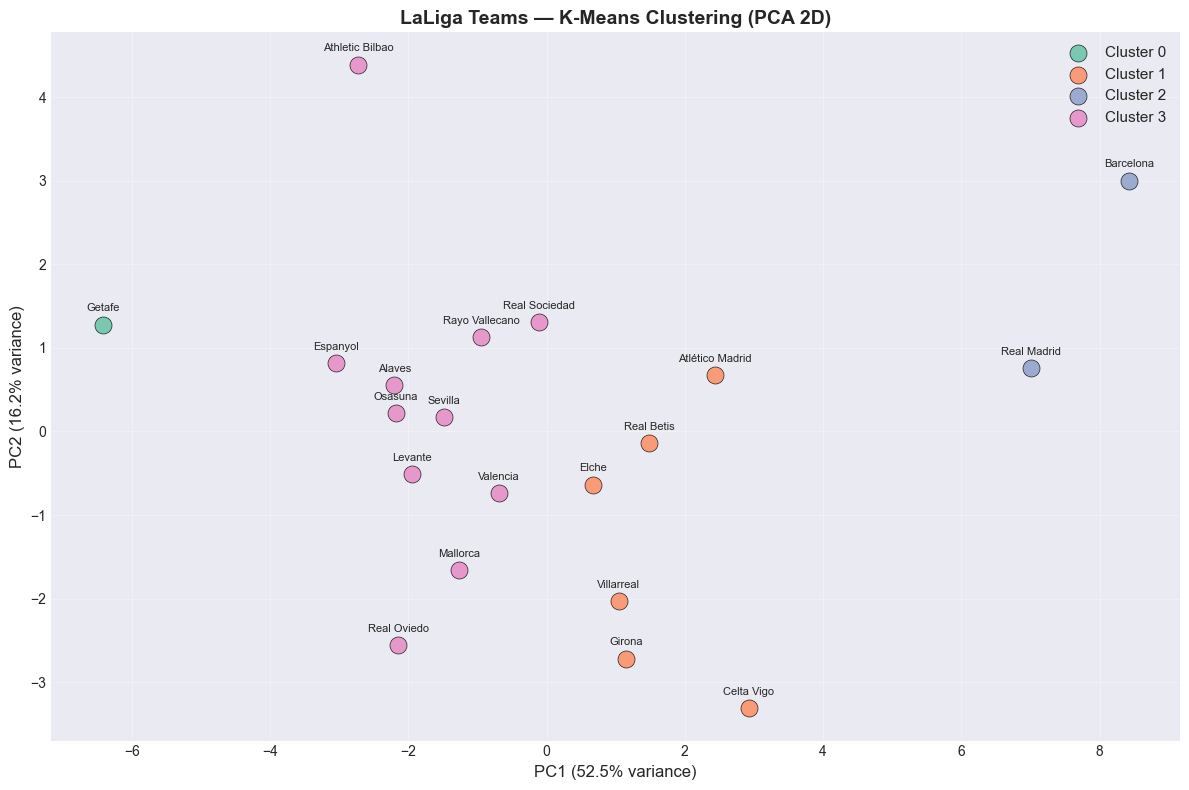


Total variance explained by 2 PCs: 68.7%


In [46]:
# PCA reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))

colors = sns.color_palette('Set2', FINAL_K)
for c in range(FINAL_K):
    mask = gold['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[c]], s=150, edgecolors='black', linewidth=0.5,
               label=f'Cluster {c}', alpha=0.85, zorder=5)

# Label each team
for i, club in enumerate(gold.index):
    ax.annotate(club, (X_pca[i, 0], X_pca[i, 1]),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('LaLiga Teams — K-Means Clustering (PCA 2D)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

### 4.6 Cluster Profiles — Karakteristik Gaya Bermain

In [47]:
# Mean of each cluster for key metrics
profile_cols = [
    'def_avg_possession_pct', 'att_goals_per_game', 'att_xg_per_game',
    'pas_passes_pct', 'pas_through_balls_per_game', 'pas_crosses_per_game',
    'prs_ppda', 'prs_pressed_seqs_per_game', 'prs_start_distance',
    'def_tackles_per_game', 'def_ground_duels_won_pct',
    'seq_direct_speed', 'seq_passes_per_seq', 'seq_buildups_per_game',
    'seq_direct_attacks_per_game', 'msc_fouls_per_game',
]

cluster_profiles = gold.groupby('cluster')[profile_cols].mean().round(2)
cluster_profiles.index.name = 'Cluster'
cluster_profiles.T

Cluster,0,1,2,3
def_avg_possession_pct,40.10,51.15,64.10,47.71
att_goals_per_game,0.84,1.46,2.26,1.16
att_xg_per_game,0.80,1.38,2.16,1.24
pas_passes_pct,69.10,85.20,89.85,80.92
pas_through_balls_per_game,0.66,2.04,2.86,1.18
pas_crosses_per_game,13.39,10.97,9.88,14.04
prs_ppda,11.70,13.18,10.10,12.10
prs_pressed_seqs_per_game,13.08,10.01,11.66,10.71
prs_start_distance,42.70,40.42,43.60,41.66
def_tackles_per_game,18.00,16.52,15.90,16.54


### 4.7 Radar Chart per Cluster

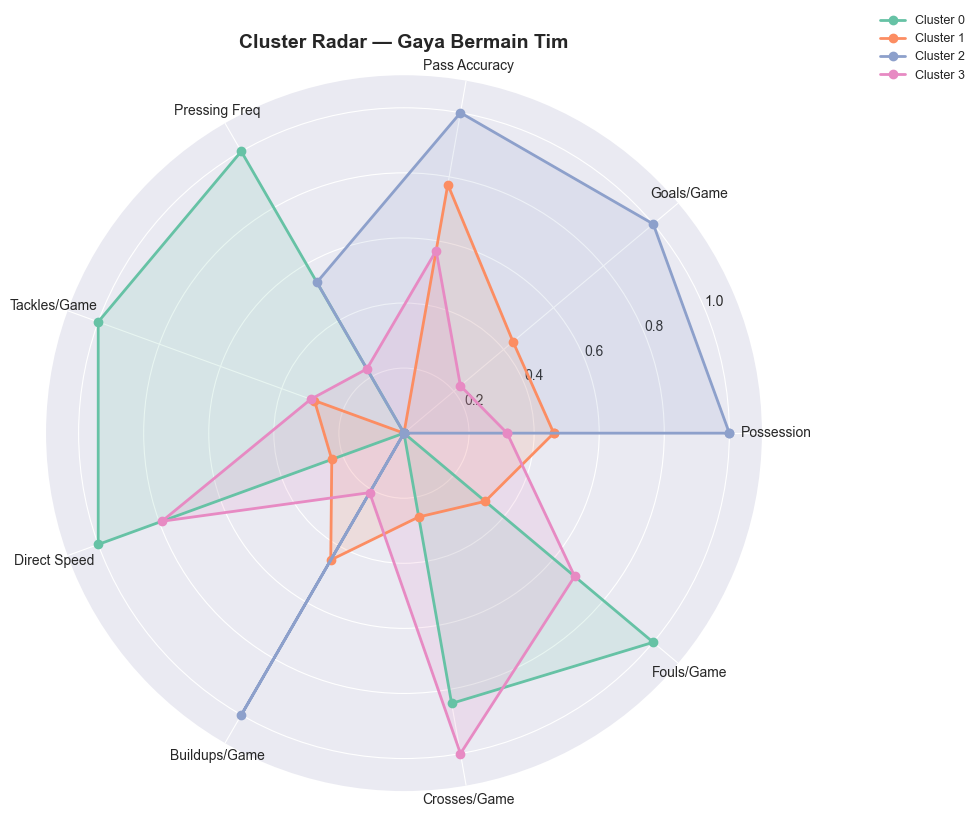

In [48]:
# Radar chart — normalized per feature (min-max to 0-1)
radar_cols = [
    'def_avg_possession_pct', 'att_goals_per_game', 'pas_passes_pct',
    'prs_pressed_seqs_per_game', 'def_tackles_per_game',
    'seq_direct_speed', 'seq_buildups_per_game',
    'pas_crosses_per_game', 'msc_fouls_per_game',
]

radar_labels = [
    'Possession', 'Goals/Game', 'Pass Accuracy',
    'Pressing Freq', 'Tackles/Game',
    'Direct Speed', 'Buildups/Game',
    'Crosses/Game', 'Fouls/Game',
]

# Normalize to 0-1
cluster_means = gold.groupby('cluster')[radar_cols].mean()
radar_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

# Radar plot
angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = sns.color_palette('Set2', FINAL_K)

for c in range(FINAL_K):
    values = radar_norm.loc[c].tolist()
    values += values[:1]  # close
    teams = ', '.join(gold[gold['cluster'] == c].index.tolist())
    label = f'Cluster {c} ({teams})'
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[c], label=f'Cluster {c}')
    ax.fill(angles, values, alpha=0.15, color=colors[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('Cluster Radar — Gaya Bermain Tim', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

### 4.8 Heatmap — Semua Tim vs Fitur (Sorted by Cluster)

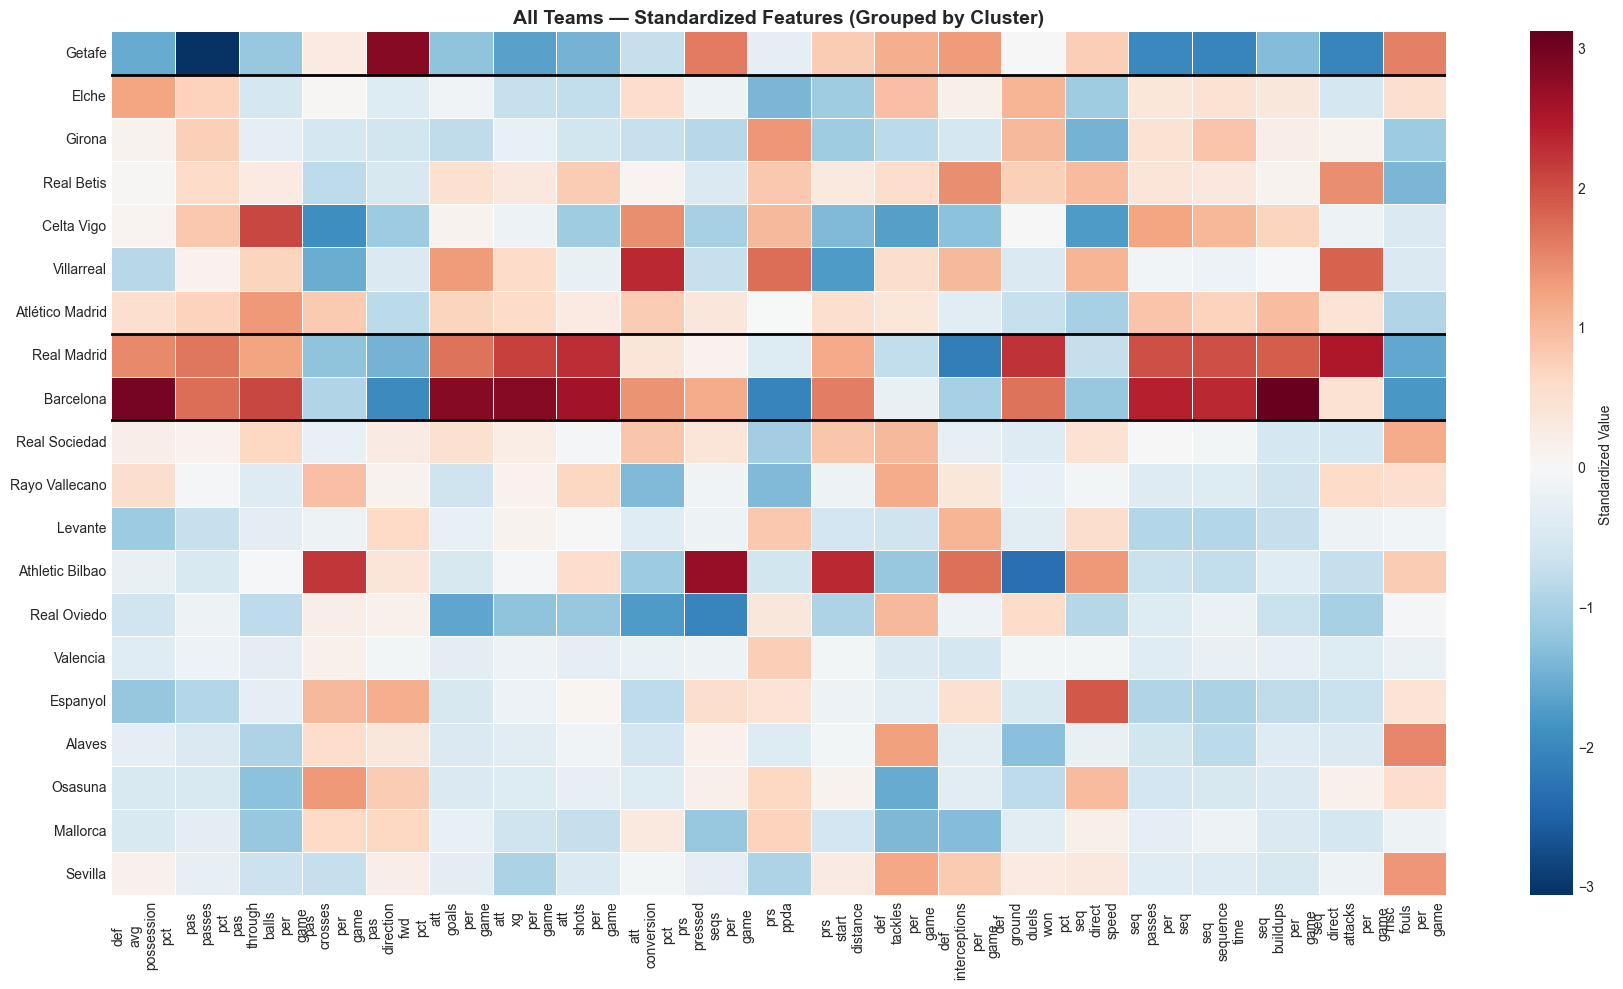

In [49]:
# Heatmap of all teams, sorted by cluster
gold_sorted = gold.sort_values('cluster')
heatmap_data = X_scaled_df.loc[gold_sorted.index]

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, linewidths=0.5,
            yticklabels=True, xticklabels=[c.replace('_', '\n') for c in style_features],
            ax=ax, cbar_kws={'label': 'Standardized Value'})

# Add cluster dividers
cluster_sizes = gold_sorted.groupby('cluster').size().cumsum().values[:-1]
for pos in cluster_sizes:
    ax.axhline(y=pos, color='black', linewidth=2)

ax.set_title('All Teams — Standardized Features (Grouped by Cluster)', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.9 Interpretasi Cluster

Jalankan cell di bawah untuk melihat ringkasan interpretasi setiap cluster.

In [50]:
# ============================================================
# Style Profiling — setiap cluster punya CAMPURAN gaya bermain
# ============================================================
# Tidak ada tim yang bermain 1 gaya saja sepanjang musim.
# Setiap cluster di-score ke 4 dimensi gaya bermain.
# Hasilnya: profil campuran (bukan label tunggal).
#
# Definisi dimensi gaya bermain:
#   Possession (Tiki-Taka)     : possession tinggi, pass accuracy, buildups, tempo lambat
#   High Pressing (Gegen)      : ppda rendah, pressing freq tinggi, start_distance tinggi
#   Direct & Counter-Attack    : direct_speed tinggi, direct_attacks, possession rendah
#   Low Block (Park the Bus)   : possession rendah, pressing rendah, clearances/tackles tinggi

from sklearn.preprocessing import MinMaxScaler

style_dimensions = {
    'Possession': {
        'high': ['def_avg_possession_pct', 'pas_passes_pct', 'seq_passes_per_seq',
                 'seq_buildups_per_game', 'seq_sequence_time'],
        'low':  ['seq_direct_speed'],
    },
    'High Pressing': {
        'high': ['prs_pressed_seqs_per_game', 'prs_start_distance', 'def_tackles_per_game'],
        'low':  ['prs_ppda'],
    },
    'Direct/Counter': {
        'high': ['seq_direct_speed', 'seq_direct_attacks_per_game',
                 'pas_direction_fwd_pct', 'att_conversion_pct'],
        'low':  ['def_avg_possession_pct', 'seq_passes_per_seq'],
    },
    'Low Block': {
        'high': ['def_tackles_per_game', 'def_interceptions_per_game',
                 'def_ground_duels_won_pct', 'msc_fouls_per_game'],
        'low':  ['def_avg_possession_pct', 'prs_pressed_seqs_per_game',
                 'prs_start_distance', 'att_shots_per_game'],
    },
}

# Normalize fitur ke 0-1
norm_scaler = MinMaxScaler()
X_norm = pd.DataFrame(
    norm_scaler.fit_transform(gold[style_features]),
    index=gold.index, columns=style_features
)

# Hitung style score per TIM (0-100)
team_style_scores = {}
for team in gold.index:
    team_data = X_norm.loc[[team]]
    scores = {}
    for style_name, metrics in style_dimensions.items():
        high_score = team_data[metrics['high']].mean().mean()
        low_score = (1 - team_data[metrics['low']]).mean().mean()
        scores[style_name] = round((high_score * 0.6 + low_score * 0.4) * 100, 1)
    team_style_scores[team] = scores

team_styles_df = pd.DataFrame(team_style_scores).T
team_styles_df['Dominant Style'] = team_styles_df[list(style_dimensions.keys())].idxmax(axis=1)

# Hitung style profile per CLUSTER (rata-rata dari anggotanya)
print("=" * 70)
print("STYLE PROFILE PER CLUSTER (campuran, bukan label tunggal)")
print("=" * 70)

for c in sorted(gold['cluster'].unique()):
    teams = gold[gold['cluster'] == c].index.tolist()
    cluster_styles = team_styles_df.loc[teams, list(style_dimensions.keys())]
    avg_scores = cluster_styles.mean().round(1)
    dominant = avg_scores.idxmax()

    print(f"\nCluster {c} ({len(teams)} tim): {', '.join(teams)}")
    print(f"  {'─' * 50}")
    for style_name in style_dimensions.keys():
        score = avg_scores[style_name]
        bar = '█' * int(score / 5) + '░' * (20 - int(score / 5))
        marker = ' ◄ dominant' if style_name == dominant else ''
        print(f"  {style_name:20s} {bar} {score:5.1f}{marker}")

print(f"\n{'=' * 70}")
print("STYLE SCORES PER TIM")
print("=" * 70)
print(team_styles_df.to_string())

STYLE PROFILE PER CLUSTER (campuran, bukan label tunggal)

Cluster 0 (1 tim): Getafe
  ──────────────────────────────────────────────────
  Possession           ██░░░░░░░░░░░░░░░░░░  12.5
  High Pressing        █████████████░░░░░░░  68.2
  Direct/Counter       █████████████░░░░░░░  69.0
  Low Block            ███████████████░░░░░  76.5 ◄ dominant

Cluster 1 (6 tim): Villarreal, Atlético Madrid, Real Betis, Celta Vigo, Girona, Elche
  ──────────────────────────────────────────────────
  Possession           ███████████░░░░░░░░░  59.4 ◄ dominant
  High Pressing        ██████░░░░░░░░░░░░░░  34.9
  Direct/Counter       █████████░░░░░░░░░░░  47.4
  Low Block            ███████████░░░░░░░░░  58.3

Cluster 2 (2 tim): Barcelona, Real Madrid
  ──────────────────────────────────────────────────
  Possession           █████████████████░░░  86.6 ◄ dominant
  High Pressing        █████████████░░░░░░░  66.2
  Direct/Counter       █████░░░░░░░░░░░░░░░  29.6
  Low Block            ██████░░░░░░░░░░░░░░

### 4.10 Style Profile per Tim — Radar Chart

In [ ]:
# Style profile per tim — semua tim di-plot
fig, ax = plt.subplots(figsize=(14, 8))

style_names = list(style_dimensions.keys())
x = np.arange(len(gold.index))
width = 0.2

colors_style = {'Possession': '#3498db', 'High Pressing': '#e74c3c',
                'Direct/Counter': '#2ecc71', 'Low Block': '#9b59b6'}

for i, style in enumerate(style_names):
    vals = team_styles_df.loc[gold.sort_values('cluster').index, style]
    ax.bar(x + i * width, vals, width, label=style, color=colors_style[style], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(gold.sort_values('cluster').index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Style Score (0-100)')
ax.set_title('Style Profile per Tim — Campuran Gaya Bermain', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 100)

# Cluster dividers
cluster_sizes = gold.sort_values('cluster').groupby('cluster').size().cumsum().values[:-1]
for pos in cluster_sizes:
    ax.axvline(x=pos - 0.5, color='black', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# Radar chart — style MIX per cluster
fig, axes = plt.subplots(1, FINAL_K, figsize=(6*FINAL_K, 6), subplot_kw=dict(polar=True))
if FINAL_K == 1:
    axes = [axes]

style_names = list(style_dimensions.keys())
angles = np.linspace(0, 2 * np.pi, len(style_names), endpoint=False).tolist()
angles += angles[:1]

colors = sns.color_palette('Set2', FINAL_K)

for c in range(FINAL_K):
    ax = axes[c] if FINAL_K > 1 else axes[0]
    teams = gold[gold['cluster'] == c].index.tolist()
    if not teams:
        continue

    # Average style scores for this cluster
    avg_scores = team_styles_df.loc[teams, style_names].mean()
    values = avg_scores.tolist() + [avg_scores.tolist()[0]]
    dominant = avg_scores.idxmax()

    ax.plot(angles, values, 'o-', linewidth=2, color=colors[c])
    ax.fill(angles, values, alpha=0.2, color=colors[c])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(style_names, fontsize=9)
    ax.set_ylim(0, 100)

    team_str = ', '.join(teams[:3])
    if len(teams) > 3:
        team_str += f'... +{len(teams)-3}'
    ax.set_title(f'Cluster {c}\nDominant: {dominant}\n({team_str})',
                 fontsize=10, fontweight='bold', pad=15)

plt.suptitle('Style Mix per Cluster (bukan label tunggal)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 5. Simpan Hasil Clustering

In [ ]:
# Save results
output_dir = BASE_DIR / "data" / "gold" / "teams"
output_dir.mkdir(parents=True, exist_ok=True)

# Gold OBT + cluster
gold.to_csv(output_dir / "teams_statistics_clustered.csv")
print(f"✅ Saved: {output_dir / 'teams_statistics_clustered.csv'}")

# Style scores per tim (campuran)
team_styles_df.to_csv(output_dir / "team_style_scores.csv")
print(f"✅ Saved: {output_dir / 'team_style_scores.csv'}")

# Cluster profiles
cluster_summary = gold.groupby('cluster')[profile_cols].mean().round(2)
cluster_summary.to_csv(output_dir / "cluster_profiles.csv")
print(f"✅ Saved: {output_dir / 'cluster_profiles.csv'}")

print(f"\n📋 Final: {len(gold)} tim → {FINAL_K} cluster")
print(f"   Setiap tim punya 4 style score (campuran, bukan 1 label)")